# Análise dos Maiores Chutadores no Campeonato Brasileiro 2025 

## Introdução

Neste projeto, realizamos uma análise detalhada dos dados do Campeonato Brasileiro 2025 para identificar os maiores chutadores da competição, com foco principal na distância média dos chutes. Além disso, consideramos critérios como a quantidade de gols, Expected Goals (xG), total de chutes e xG por chute.

## Metodologia

1. **Coleta de Dados:** Utilizamos os dados reais do Campeonato Brasileiro 2025 fornecidos pela Opta, via FotMob, incluindo informações sobre rodadas, jogadores, partidas, gols marcados, distância média dos chutes e outras estatísticas relevantes.

2. **Cálculo das Métricas:** Calculamos as seguintes métricas para cada jogador:
   - **Gols:** Número total de gols marcados por cada jogador ao longo do campeonato.
   - **Expected Goals (xG):** Uma estimativa de probabilidade de um chute resultar em gol, considerando diversas variáveis.
   - **Total de Chutes:** Número total de chutes a gol feitos por cada jogador.
   - **Distância Média dos Chutes:** Média da distância dos chutes a gol para cada jogador.
   - **xG por Chute:** Média de Expected Goals por chute realizado.

3. **Seleção dos Melhores Chutadores:** Levando em consideração a distância média dos chutes e as métricas mencionadas acima, identificamos os 6 melhores chutadores do campeonato.


In [1]:
#Importar as bibliotecas

import json
import re
import csv
from time import sleep
import time
import urllib
import os

from lxml import etree

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import matplotlib.patheffects as path_effects
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from matplotlib import rcParams
from highlight_text import fig_text, ax_text
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import RegularPolygon
from matplotlib import cm
from PIL import Image

from mplsoccer import Pitch, VerticalPitch

import pprint

from IPython.display import clear_output
#from ScraperFC.shared_functions import *
import json
import random

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [2]:
#Rodada para a análise 
rodada = 33
r = 33  # Rodada
resultados = []
p = 0

In [3]:
#Carregamento dos Dados
new_df = pd.read_json(r'G:\pythonProject\Eventos_Brasileirão\data\processed\br25_fotmob.json')
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 340 entries, 0 to 339
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   general        340 non-null    object
 1   header         340 non-null    object
 2   nav            340 non-null    object
 3   ongoing        340 non-null    bool  
 4   hasPendingVAR  340 non-null    bool  
 5   content        340 non-null    object
 6   seo            340 non-null    object
dtypes: bool(2), object(5)
memory usage: 16.6+ KB


In [4]:
new_df.head(4)

,general,header,nav,ongoing,hasPendingVAR,content,seo
0,"{'matchId': '4732480', 'matchName': 'Cruzeiro-...","{'teams': [{'name': 'Cruzeiro', 'id': 9781, 's...","[matchfacts, liveticker, lineup, stats, table,...",False,False,"{'matchFacts': {'matchId': 4732480, 'highlight...","{'path': 'cruzeiro-vs-mirassol', 'eventJSONLD'..."
1,"{'matchId': '4732483', 'matchName': 'Fortaleza...","{'teams': [{'name': 'Fortaleza', 'id': 8287, '...","[matchfacts, liveticker, lineup, stats, table,...",False,False,"{'matchFacts': {'matchId': 4732483, 'highlight...","{'path': 'fortaleza-vs-fluminense', 'eventJSON..."
2,"{'matchId': '4732481', 'matchName': 'Gremio-vs...","{'teams': [{'name': 'Gremio', 'id': 9769, 'sco...","[matchfacts, liveticker, lineup, stats, table,...",False,False,"{'matchFacts': {'matchId': 4732481, 'highlight...","{'path': 'gremio-vs-atletico-mg', 'eventJSONLD..."
3,"{'matchId': '4732484', 'matchName': 'Juventude...","{'teams': [{'name': 'Juventude', 'id': 10274, ...","[matchfacts, liveticker, lineup, stats, table,...",False,False,"{'matchFacts': {'matchId': 4732484, 'highlight...","{'path': 'juventude-vs-vitoria', 'eventJSONLD'..."


In [5]:
# Renomear as colunas
new_df = new_df.rename(columns=lambda x: x.replace('.', '_'))

In [6]:
#Verificação do DataFrame
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 340 entries, 0 to 339
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   general        340 non-null    object
 1   header         340 non-null    object
 2   nav            340 non-null    object
 3   ongoing        340 non-null    bool  
 4   hasPendingVAR  340 non-null    bool  
 5   content        340 non-null    object
 6   seo            340 non-null    object
dtypes: bool(2), object(5)
memory usage: 16.6+ KB


In [7]:
# Lista de chaves a serem removidas

chaves_remover = ['h2h', 'matchesInRound', 'poll', 'insights', 'topScorers', 'countryCode',
                  'QAData', 'liveticker', 'buzz', 'playoff', 'table', 'teams',
                  'tournamentNameForUrl', 'parentLeagueId', 'parentLeagueName',
                  'isCurrentSeason', 'parentLeagueSeason', 'countryCode']

# Percorrer todas as linhas do DataFrame
for index, row in new_df.iterrows():
    # Verificar se a coluna 'content' contém um dicionário
    if isinstance(row['content'], dict):
        # Remover as chaves da lista 'chaves_remover' do dicionário
        for chave in chaves_remover:
            if chave in row['content']:
                del row['content'][chave]

In [8]:
# Lista de colunas a serem removidas
colunas_remover = ['nav', 'ongoing', 'hasPendingVAR', 'general_teamColors_lightMode_home',
                   'general_teamColors_lightMode_away', 'general_teamColors_fontDarkMode_home',
                   'general_teamColors_fontDarkMode_away', 'general_teamColors_fontLightMode_home',
                   'general_teamColors_fontLightMode_away', 'general_started', 'general_finished',
                   'header_status_utcTime', 'header_status_finished', 'header_status_started',
                   'header_status_cancelled', 'header_status_reason_short', 'header_status_reason_shortKey',
                   'header_status_reason_long', 'header_status_reason_longKey',
                   'content_matchFacts_poll_oddspoll_Facts', 'content_matchFacts_poll_oddspoll_PollName',
                   'content_matchFacts_poll_oddspoll_MatchId', 'seo_faqJSONLD_mainEntity',
                   'seo_faqJSONLD_@type', 'seo_faqJSONLD_@context', 'seo_breadcrumbJSONLD',
                   'seo_eventJSONLD_performer', 'seo_eventJSONLD_offers_priceCurrency',
                   'seo_eventJSONLD_offers_price', 'seo_eventJSONLD_offers_availability',
                   'seo_eventJSONLD_offers_url', 'seo_eventJSONLD_offers_@type',
                   'seo_eventJSONLD_organizer_logo', 'seo_eventJSONLD_organizer_url',
                   'seo_eventJSONLD_organizer_name', 'seo_eventJSONLD_organizer_@type',
                   'seo_eventJSONLD_image', 'seo_eventJSONLD_location_url',
                   'seo_eventJSONLD_location_@type', 'seo_eventJSONLD_eventAttendanceMode',
                   'seo_eventJSONLD_eventStatus', 'seo_eventJSONLD_endDate', 'seo_eventJSONLD_startDate',
                   'seo_eventJSONLD_description', 'seo_eventJSONLD_name', 'seo_eventJSONLD_awayTeam_url',
                   'seo_eventJSONLD_awayTeam_logo', 'seo_eventJSONLD_awayTeam_sport',
                   'seo_eventJSONLD_awayTeam_name', 'seo_eventJSONLD_awayTeam_@type',
                   'seo_eventJSONLD_awayTeam_@context', 'seo_eventJSONLD_homeTeam_url',
                   'seo_eventJSONLD_homeTeam_logo', 'seo_eventJSONLD_homeTeam_sport',
                   'seo_eventJSONLD_homeTeam_name', 'seo_eventJSONLD_homeTeam_@type',
                   'seo_eventJSONLD_homeTeam_@context', 'seo_eventJSONLD_sport', 'seo_eventJSONLD_@type',
                   'seo_eventJSONLD_@context', 'seo_path', 'content_matchFacts_momentum_main_debugTitle']

# Iterar em todas as linhas do DataFrame
for index, row in new_df.iterrows():
    # Remover as colunas da lista 'colunas_remover'
    new_df.loc[index, colunas_remover] = pd.NA

# Remover as colunas com valores NA
new_df = new_df.dropna(axis=1, how='all')

In [9]:
new_df['content'][0]['shotmap']['shots'][0]['']

KeyError: ''

In [10]:
#Criar um dicionário para todos os eventos de cada jogo
total_jogos = len(new_df.content)

jogo = 0
todos_os_dicionarios = []

while jogo < total_jogos:
    tamanho = len(new_df.content[jogo]['shotmap']['shots'])
    eventos = []
    jogo_id = new_df.content[jogo]['matchFacts']['matchId']  # Obter o ID do jogo

    for i in range(tamanho):
        evento = new_df.content[jogo]['shotmap']['shots'][i]
        evento['matchId'] = jogo_id  # Adicionar o ID do jogo ao dicionário do evento
        eventos.append(evento)

    todos_os_dicionarios.extend(eventos)

    jogo += 1

df_resultado = pd.DataFrame(todos_os_dicionarios)

In [11]:
# Jogadores para a seleção
df_resultado['playerName'].unique()

array(['Danielzinho', 'Dudu', 'Kaio Jorge', 'Gabriel Barbosa', 'Clayson',
       'Neto', 'Chico', 'Reinaldo', 'Jemmes', 'Lucas Ramon', 'William',
       'Edson Carioca', 'Matheus Davo', 'Luis Silva',
       'Juan Martin Lucero', 'German Cano', 'Tinga', 'Vinicius Lima',
       'Yago Pikachu', 'Leandro Martinez', 'Guga', 'Hercules', 'Marinho',
       'Martinelli', 'Keno', 'Ruben Lezcano', 'Tomas Cuello',
       'Francis Amuzu', 'Rony', 'Hulk', 'Camilo', 'Lucas Esteves',
       'Matias Arezo', 'Gabriel Menino', 'Edenilson', 'Guilherme Arana',
       'Junior Santos', 'Andre', 'Gustavo Scarpa', 'Cristian Pavon',
       'Rubens', 'Joao Marcelo', 'Bill', 'Enio', 'Neris', 'Jamerson',
       'Gustavo Mosquito', 'Wellington Rato', 'Adriano Martins',
       'Janderson', 'Emerson Batalla', 'Ewerton', 'Leo Pereira',
       'Willian', 'Fabricio', 'Jonathan Calleri', 'Sabino', 'Hereda',
       'Sérgio Oliveira', 'Alan Franco', 'Luiz Gustavo', 'Igor Vinicius',
       'Lenny Lobato', 'Lucas Lima', 'Mat

In [12]:
#Criando a extrutura para plotar a VIZ
goleadores_data = []  # Lista para armazenar os dicionários

for index, row in df_resultado.iterrows():
    goleador = {
        'teamId': row['teamId'],
        'playerId': row['playerId'],
        'playerName': row['playerName'],
        'min': row['min'],
        'xG': row['expectedGoals'],
        'teamColor': row['teamColor'],
        'eventType': row['eventType'],
        'match_id': row['matchId'],
        'isOwnGoal': row['isOwnGoal'],
        'x': row['x'],
        'y': row['y'],
        'situation': row['situation'],
        'teamName': row['teamId'],  
    }
    goleadores_data.append(goleador)

# Criando o DataFrame a partir da lista de dicionários
goleadores = pd.DataFrame(goleadores_data)


In [13]:
goleadores.to_json('D:/pythonProject/football/Melhores_Chutadores/data/processed/goleadores_processed_br25.json')

In [44]:
goleadores = pd.read_json('D:/pythonProject/football/Melhores_Chutadores/data/processed/goleadores_processed_br25.json')

In [45]:
#Carregando as fontes e o estilo do relatório
font_path = 'D:/pythonProject/football/Melhores_Chutadores/config/fonts'
for x in os.listdir(font_path):
    for y in os.listdir(f"{font_path}/{x}"):
        if y.split(".")[-1] == "otf":
            fm.fontManager.addfont(f"{font_path}/{x}/{y}")
            try:
                fm.FontProperties(weight=y.split("-")[-1].split(".")[0].lower(), fname=y.split("-")[0])
            except Exception:
                continue

plt.style.use("D:/pythonProject/football/Melhores_Chutadores/config/stylesheets/soc_base.mplstyle")
plt.rcParams['font.family'] = 'Nippo'

In [46]:
#Filtrando e excluindo os penalts
goleadores = goleadores[goleadores['situation'] != 'Penalty'].reset_index(drop=True)
goleadores.head(5)

,teamId,playerId,playerName,min,xG,teamColor,eventType,match_id,isOwnGoal,x,y,situation,teamName
0,163782,493553,Danielzinho,10,0.098833,#d99f00,AttemptSaved,4732480,False,81.696602,31.636250,FreeKick,163782
1,9781,174531,Dudu,14,0.563304,#294492,Goal,4732480,False,98.824561,36.592500,RegularPlay,9781
2,9781,964661,Kaio Jorge,18,0.111454,#294492,Miss,4732480,False,96.605263,34.457500,FromCorner,9781
3,9781,450848,Gabriel Barbosa,22,0.337059,#294492,Goal,4732480,False,97.473684,30.232000,RegularPlay,9781
4,163782,629937,Clayson,25,0.015354,#d99f00,AttemptSaved,4732480,False,75.502427,50.656815,RegularPlay,163782


In [47]:
#Verifica se um chute está dentro das dimensões da nossa área.
def is_inside_box(x,y):
    if (x >= 13.84) & (x <= 54.16) & (y >=88.5):
        return True
    else:
        return False

## Filtrar pelo time

In [48]:
goleadores = goleadores[goleadores['teamId'] == 10283]

In [49]:
# Nós invertemos os dados porque estamos analisando um Campo Vertical.
goleadores['is_in_box'] = [is_inside_box(x,y) for x,y in zip(goleadores['y'], goleadores['x'])]
data_groupped = goleadores.groupby(['playerId', 'playerName', 'teamId', 'is_in_box'])['min'].count().reset_index()

In [50]:
#Pivotar os dados e corrigir os valores ausentes
data_groupped = data_groupped.pivot(columns='is_in_box', index=['playerId', 'playerName', 'teamId'], values='min').reset_index()
#data_groupped.columns = ['playerId', 'playerName', 'teamId', 'False', 'True']
data_groupped.columns = ['playerId', 'playerName', 'teamId', 'False', 'True']
data_groupped.fillna(0, inplace=True)

In [51]:
# Calcula o total de chutes e a proporção de chutes na área
data_groupped['total'] = data_groupped['False'] + data_groupped['True']
data_groupped['share'] = data_groupped['True']/data_groupped['total']

In [52]:
data_groupped.columns.to_list()

['playerId', 'playerName', 'teamId', 'False', 'True', 'total', 'share']

# Filtrar por Jogador

In [53]:
data_groupped[data_groupped['playerName'] == 'Vitor Roque']

,playerId,playerName,teamId,False,True,total,share
21,1339347,Vitor Roque,10283,16.0,57.0,73.0,0.780822


In [54]:
# Seleciona e exibe os 6 principais jogadores com base no total de chutes
data_groupped = (
    data_groupped
    .sort_values(by='total', ascending=False)
    .head(6)
)
data_groupped

,playerId,playerName,teamId,False,True,total,share
19,1216079,Jose Lopez,10283,24.0,51.0,75.0,0.680000
21,1339347,Vitor Roque,10283,16.0,57.0,73.0,0.780822
14,1059490,Mauricio,10283,18.0,16.0,34.0,0.470588
10,861661,Joaquin Piquerez,10283,24.0,5.0,29.0,0.172414
1,230190,Felipe Anderson,10283,19.0,10.0,29.0,0.344828
17,1139168,Facundo Torres,10283,8.0,18.0,26.0,0.692308


In [55]:
'''
player_id_a_modificar = 466164

# Suponha que você tenha novos dados para substituir na linha
novos_dados = {
    'playerId'      : 751198,
    'playerName'    : 'De La Cruz',
    'teamId'        : 10076,
    'False'         : 24.0,
    'True'          : 15.0,
    'total'         : 39.0,
    'share'         : 0.384615
    }

# Usando o método loc para localizar a linha pelo playerId e substituir os dados
data_groupped.loc[data_groupped['playerId'] == player_id_a_modificar, :] = [novos_dados[col] for col in data_groupped.columns]
'''


"\nplayer_id_a_modificar = 466164\n\n# Suponha que você tenha novos dados para substituir na linha\nnovos_dados = {\n    'playerId'      : 751198,\n    'playerName'    : 'De La Cruz',\n    'teamId'        : 10076,\n    'False'         : 24.0,\n    'True'          : 15.0,\n    'total'         : 39.0,\n    'share'         : 0.384615\n    }\n\n# Usando o método loc para localizar a linha pelo playerId e substituir os dados\ndata_groupped.loc[data_groupped['playerId'] == player_id_a_modificar, :] = [novos_dados[col] for col in data_groupped.columns]\n"

In [56]:
# Filtra os dados dos principais goleadores com base nos jogadores do DataFrame 'data_groupped'
goleadores = goleadores[goleadores['playerId'].isin(data_groupped['playerId'])].reset_index(drop=True)

In [57]:
import matplotlib as mpl
import matplotlib.colors as mcolors

# Define sua paleta de cores
colors = [
    '#d0d6d4', '#c5d0cd', '#bbcac7', '#b0c3c1', '#a6bdbb',
    '#9bb7b5', '#91b1af', '#86aaa8', '#7ca4a2', '#719e9c',
    '#679896', '#5c9190', '#528b8a', '#478583', '#3d7f7d',
    '#327877', '#287271',
]

# Cria o mapa de cores
soc_cm = mcolors.LinearSegmentedColormap.from_list('SOC', colors, N=50)

# ✅ Registra o mapa de cores da forma correta
mpl.colormaps.register(cmap=soc_cm, name='SOC')

print("Colormap 'SOC' registrado com sucesso!")


ValueError: A colormap named "SOC" is already registered.

In [58]:
import numpy as np

# Função para gerar as coordenadas de uma semicircunferência
def semicircle(r, h, k):
    x0 = h - r  # Determina o ponto de início de x
    x1 = h + r  # Determina o ponto de término de x
    x = np.linspace(x0, x1, 10000)  # Gera muitos pontos para calcular y

    # Utiliza numpy para calcular as coordenadas y da semicircunferência
    y = k - np.sqrt(r**2 - (x - h)**2)
    return x, y


In [59]:
def plot_hexbin_shot(ax, playerId):
    """
    Plota um gráfico hexbin de chutes em um campo de futebol vertical,
    junto com anotações e informações relacionadas aos chutes.

    Parâmetros:
    - ax: Eixo do subplot onde o gráfico será plotado.
    - playerId: ID do jogador para o qual os chutes estão sendo plotados.
    """
     # Cria uma instância do campo de futebol vertical
    pitch = VerticalPitch(
        pitch_type='uefa',
        half=True,
        goal_type='box',
        linewidth=1.25,
        line_color='black',
        pad_bottom=-8,
        pad_top=10
    )
    # Desenha o campo de futebol no eixo
    pitch.draw(ax = ax)
    # Filtra os dados para o jogador específico
    aux_data = goleadores[goleadores['playerId'] == playerId]
    # Plota o gráfico hexbin dos chutes no campo
    bins = pitch.hexbin(x=aux_data['x'], y=aux_data['y'], ax=ax, cmap='SOC', gridsize=(14,14), zorder=-1, edgecolors='#efe9e6', alpha=0.9, lw=.25)
    # Calcula e plota a semicircunferência
    x_circle, y_circle = semicircle(104.8 - aux_data['x'].median(), 34, 104.8)  # function call
    ax.plot(x_circle, y_circle, ls='--', color='red', lw=.75)
    # Anotações relacionadas aos chutes
    annot_x = [54 - x*14 for x in range(0,4)]
    annot_texts = ['goals', 'xG', 'shots', 'xG/shot']
    annot_stats = [aux_data[aux_data['eventType'] == 'Goal'].shape[0], aux_data['xG'].sum(), aux_data.shape[0], aux_data['xG'].sum()/aux_data.shape[0]]
    # Adiciona hexágonos e anotações para estatísticas
    for x,s,stat in zip(annot_x, annot_texts, annot_stats):
        hex_annotation = RegularPolygon((x, 70), numVertices=6, radius=4.5, edgecolor='black', fc='None', hatch='.........', lw=1.25)
        ax.add_patch(hex_annotation)
        ax.annotate(
            xy=(x,70),
            text=s,
            xytext=(0,-14),
            textcoords='offset points',
            size=5,
            ha='center',
            va='center'
        )
        if isinstance(stat, int):
            text_stat = f'{stat:.0f}'
        else:
            text_stat = f'{stat:.2f}'
        text_ = ax.annotate(
            xy=(x,70),
            text=text_stat,
            xytext=(0,0),
            textcoords='offset points',
            size=5,
            ha='center',
            va='center',
            weight='bold'
        )
        text_.set_path_effects(
            [path_effects.Stroke(linewidth=1.5, foreground='#efe9e6'), path_effects.Normal()]
        )

    # Anotação da distância média
    median_annotation = ax.annotate(
        xy=(34,110),
        xytext=(x_circle[-1], 110),
        text=f"{((105 - aux_data['x'].median())*18)/16.5 * 0.9144:.1f} m.",
        size=4,
        color='red',
        ha='right',
        va='center',
        arrowprops=dict(arrowstyle= '<|-, head_width=0.35, head_length=0.65',
            color='red',
            fc='#efe9e6',
            lw=0.75)
    )
    # Outras anotações
    ax.annotate(
        xy=(34,110),
        xytext=(4,0),
        text=f"distância média",
        textcoords='offset points',
        size=4,
        color='red',
        ha='left',
        va='center',
        alpha=0.5
    )

    ax.annotate(
        xy=(34,114),
        text=f"{aux_data['playerName'].iloc[0].upper()}",
        size=7.5,
        color='black',
        ha='center',
        va='center',
        weight='bold'
    )

    return ax

In [60]:
data_groupped

,playerId,playerName,teamId,False,True,total,share
19,1216079,Jose Lopez,10283,24.0,51.0,75.0,0.680000
21,1339347,Vitor Roque,10283,16.0,57.0,73.0,0.780822
14,1059490,Mauricio,10283,18.0,16.0,34.0,0.470588
10,861661,Joaquin Piquerez,10283,24.0,5.0,29.0,0.172414
1,230190,Felipe Anderson,10283,19.0,10.0,29.0,0.344828
17,1139168,Facundo Torres,10283,8.0,18.0,26.0,0.692308


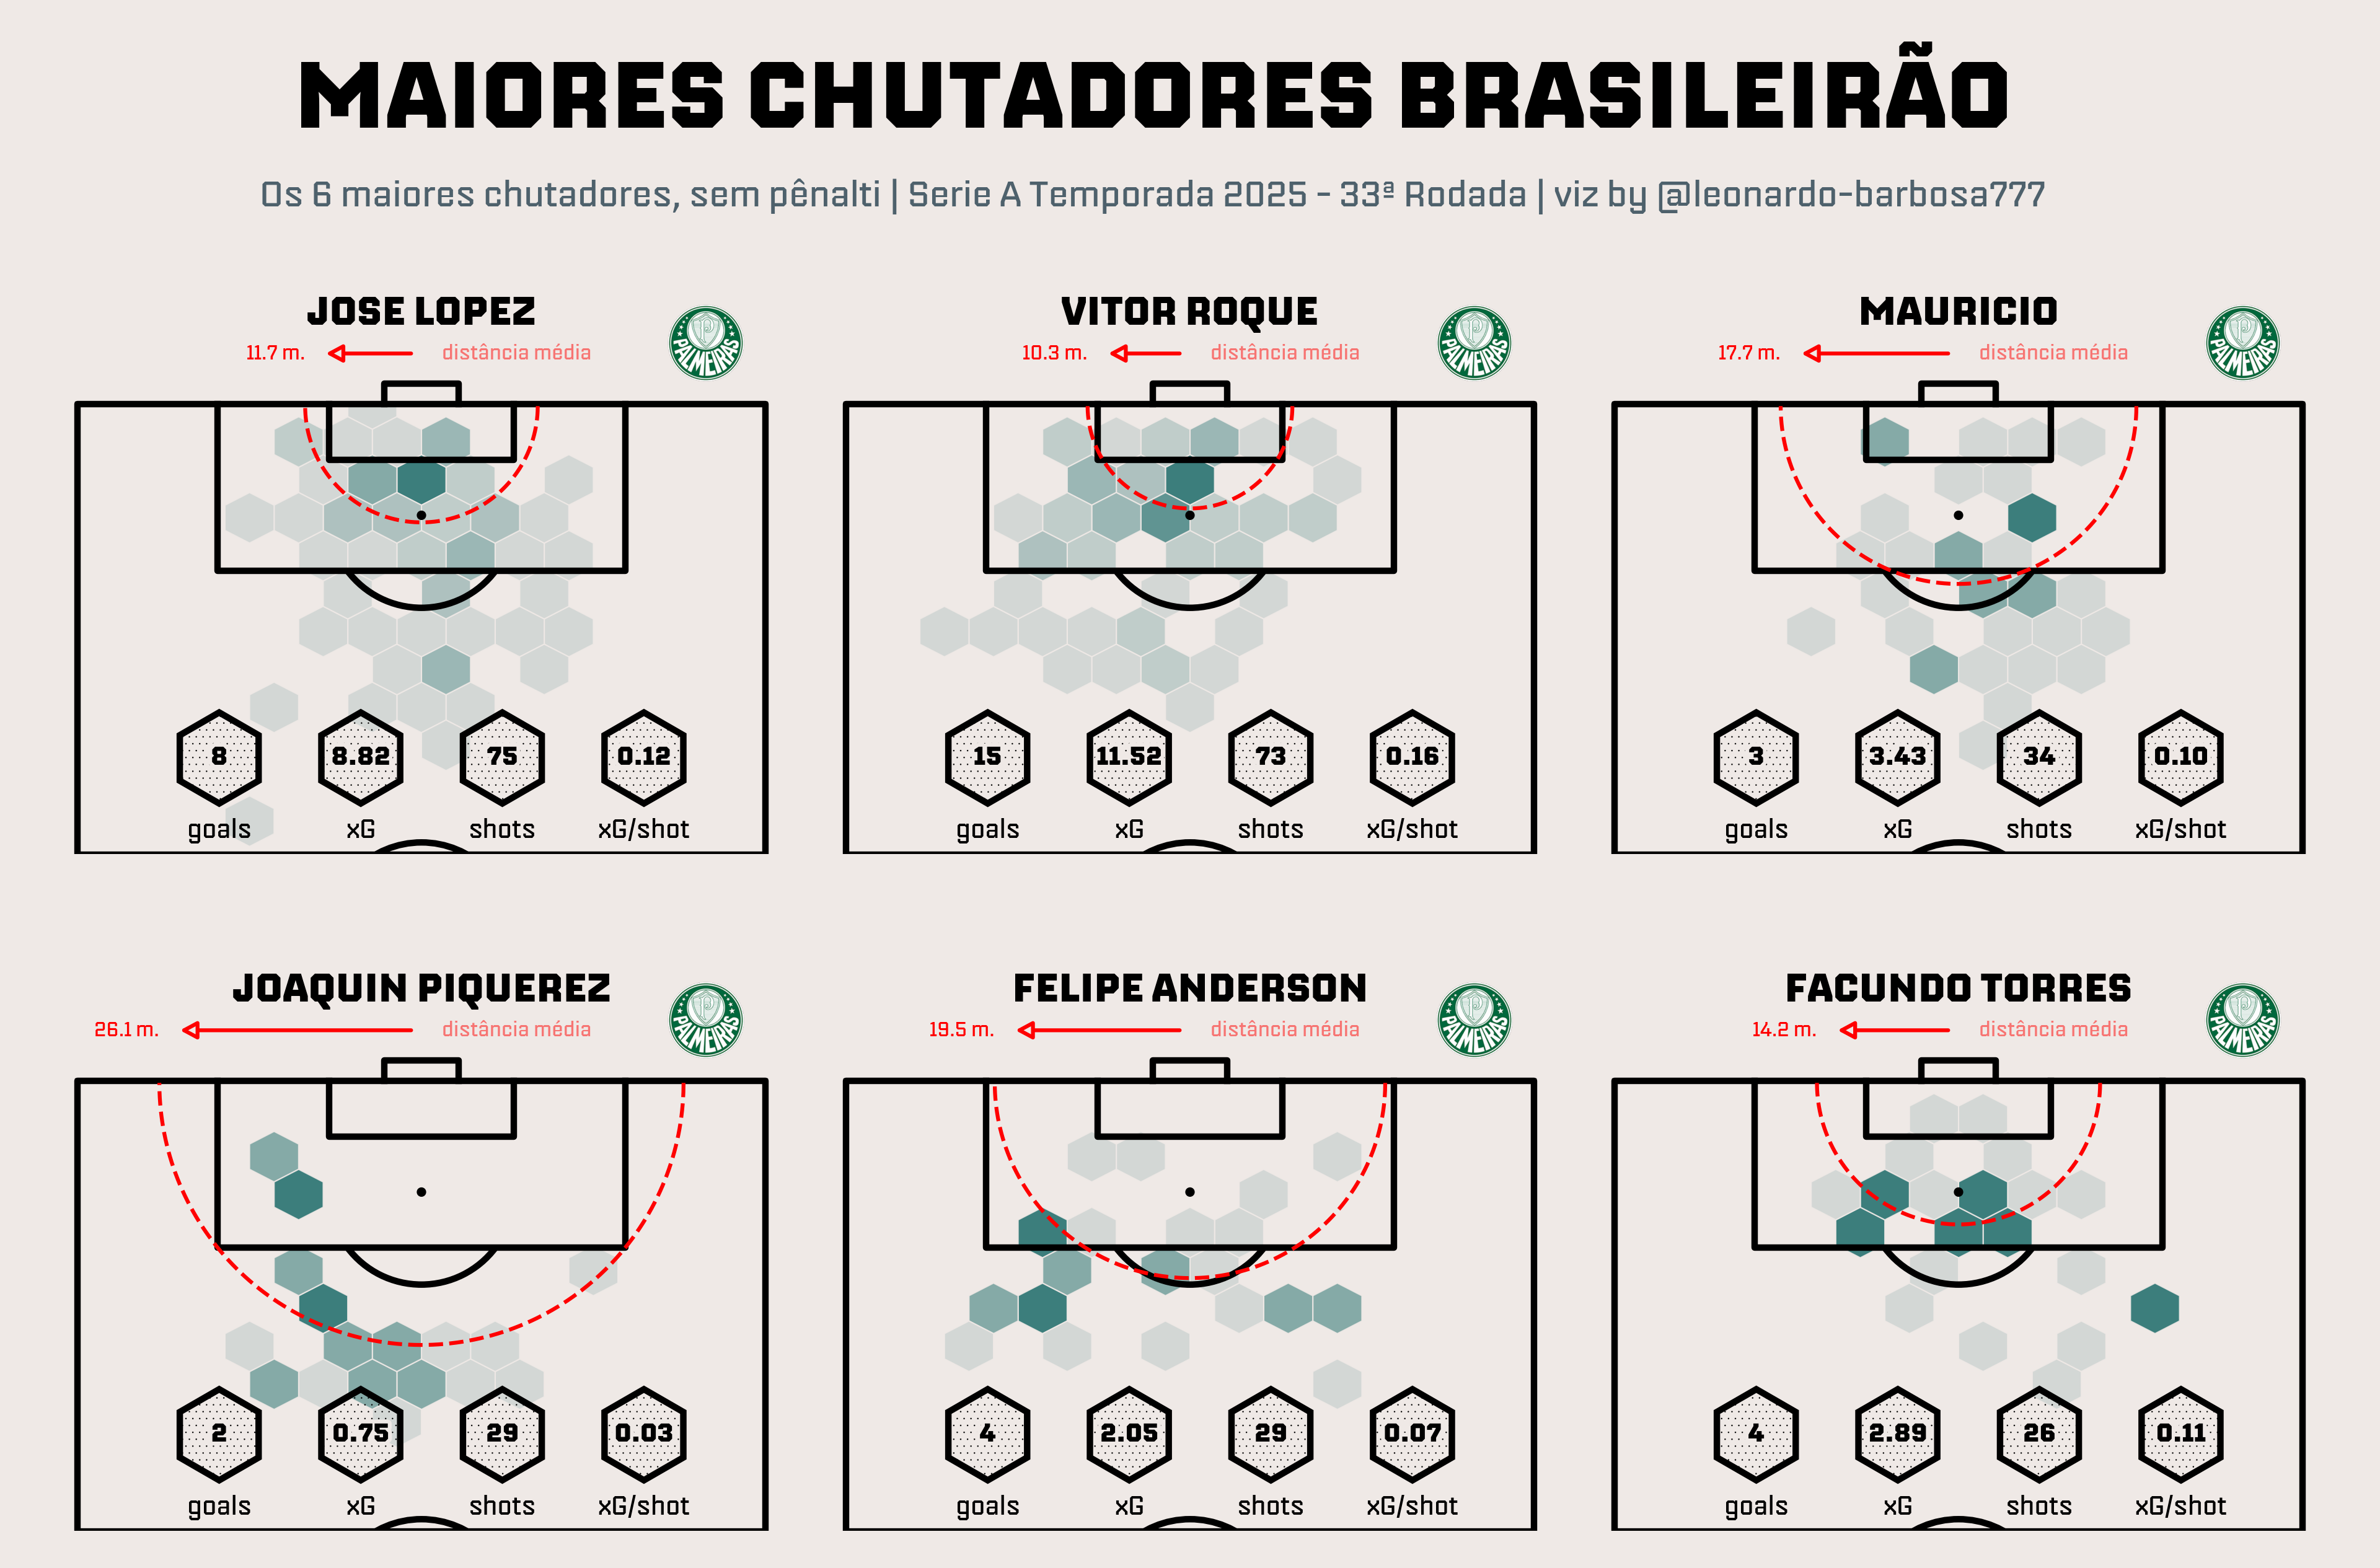

In [61]:
# Cria uma figura com 2 linhas e 3 colunas de subplots, com tamanho e resolução definidos
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(8,6), dpi=600)
axs = np.array(axs)
plt.rcParams['hatch.linewidth'] = .02

# Loop para plotar os gráficos hexbin para cada jogador nos subplots
for index, ax in enumerate(axs.reshape(-1)):
    plot_hexbin_shot(ax, data_groupped['playerId'].iloc[index])

# Ajusta os espaçamentos entre os subplots
plt.subplots_adjust(wspace=0, hspace=-.35)

# Adiciona os logos dos times aos subplots
for index, ax in enumerate(axs.reshape(-1)):
    DC_to_FC = ax.transData.transform
    FC_to_NFC = fig.transFigure.inverted().transform
    DC_to_NFC = lambda x: FC_to_NFC(DC_to_FC(x))
    ax_coords = DC_to_NFC((11,98))
    ax_size = 0.035
    image_ax = fig.add_axes(
        [ax_coords[0], ax_coords[1], ax_size, ax_size],
        fc='None'
    )
    fotmob_url = 'https://images.fotmob.com/image_resources/logo/teamlogo/'
    club_icon = Image.open(urllib.request.urlopen(f'{fotmob_url}{data_groupped["teamId"].iloc[index]:.0f}.png'))
    image_ax.imshow(club_icon)
    image_ax.axis('off')

# Adiciona textos à figura
fig_text(
    x = 0.5, y = .84,
    s = "MAIORES CHUTADORES BRASILEIRÃO",
    va = "bottom", ha = "center",
    fontsize = 18, color = "black", font = "Nippo", weight = "bold"
)
fig_text(
    x = 0.5, y = .81,
    s = f"Os 6 maiores chutadores, sem pênalti | Serie A Temporada 2025 - {rodada}ª Rodada | viz by @leonardo-barbosa777",
    va = "bottom", ha = "center",
    fontsize = 7, color = "#4E616C", font = "Nippo"
)

# Salva a figura em dois formatos diferentes
plt.savefig(
    r"G:\pythonProject\Aula_Cbf\images\top_6_shots_BR_25.png", #png
    dpi = 600,
    facecolor = "#EFE9E6",
    bbox_inches="tight",
    edgecolor="none",
    transparent = False
)

plt.savefig(
    r"G:\pythonProject\Aula_Cbf\images\top_6_shots_br_25_BR.png", #transparente
    dpi = 600,
    facecolor = "none",
    bbox_inches="tight",
    edgecolor="none",
    transparent = True
)
